In [14]:
import requests
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# This is the URL where your api.py is currently running
API_URL = "http://127.0.0.1:5000/predict"

def plot_results(image_path, api_response):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    ax = plt.gca()

    # CHANGE THIS LINE: Your API now returns "detections" instead of "results"
    detections = api_response.get("suspicious_regions", [])
    
    if not detections:
        plt.title("No Forgeries Detected")
    else:
        for res in detections:
            box = res["box"]
            # YOLO/Paddle boxes are [x1, y1, x2, y2]
            # Rectangle needs: (x, y), width, height
            rect = plt.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                                 fill=False, color='red', linewidth=2)
            ax.add_patch(rect)
            plt.text(box[0], box[1], f"{res['text']} ({res['detection_score']:.2f})",
                     bbox=dict(facecolor='red', alpha=0.5))
    
    plt.axis('off')
    plt.show()

API Response successful!


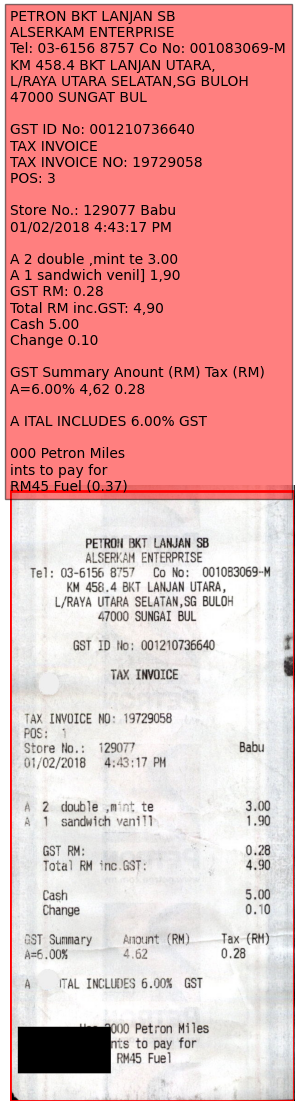

In [15]:
# 1. Path to your test image
IMAGE_TO_TEST = r"C:\Users\JERMAGNE\forgery-detect\data\train\synth_X51005230605.png"

# 2. Send the request to the Flask server
try:
    with open(IMAGE_TO_TEST, "rb") as f:
        files = {"image": f}
        response = requests.post(API_URL, files=files)
    
    if response.status_code == 200:
        data = response.json()
        print("API Response successful!")
        # 3. Visualize the result
        plot_results(IMAGE_TO_TEST, data)
    else:
        print(f"Error: {response.status_code}")
        print(response.text)
        
except Exception as e:
    print(f"Could not connect to the API. Is api.py running? \nError: {e}")

In [16]:
import json
print(json.dumps(data, indent=4))

{
    "extracted_content": [
        "PETRON BKT LANJAN SB\nALSERKAM ENTERPRISE\nTel: 03-6156 8757 Co No: 001083069-M\nKM 458.4 BKT LANJAN UTARA,\nL/RAYA UTARA SELATAN,SG BULOH\n47000 SUNGAT BUL\n\nGST ID No: 001210736640\nTAX INVOICE\nTAX INVOICE NO: 19729058\nPOS: 3\n\nStore No.: 129077 Babu\n01/02/2018 4:43:17 PM\n\nA 2 double ,mint te 3.00\nA 1 sandwich venil] 1,90\nGST RM: 0.28\nTotal RM inc.GST: 4,90\nCash 5.00\nChange 0.10\n\nGST Summary Anount (RM) Tax (RM)\nA=6.00% 4,62 0.28\n\nA ITAL INCLUDES 6.00% GST\n\n000 Petron Miles\nints to pay for\nRM45 Fuel"
    ],
    "image_level_forgery_score": 0.3722,
    "status": "success",
    "suspicious_regions": [
        {
            "box": [
                0.0,
                11.905655860900879,
                615.9734497070312,
                1336.0
            ],
            "detection_score": 0.3722377419471741,
            "field_flag": "CLEAN",
            "text": "PETRON BKT LANJAN SB\nALSERKAM ENTERPRISE\nTel: 03-6156 8757 Co 